# Project Overview

This project focuses on Exploratory Data Analysis (EDA) of retail sales data using Python. The analysis examines sales trends, customer demographics, product category performance, and purchasing behavior.

The dataset contains 1,000 retail transactions with information such as transaction date, gender, age, product category, quantity, price per unit, and total transaction amount.

The project uses Pandas, NumPy, Matplotlib, and Seaborn to clean, analyze, and visualize the data. Monthly and quarterly sales trends, age-group and gender distributions, category-level sales performance, correlations between numerical variables, and average spending across age groups are analyzed.

The goal is to identify meaningful patterns in the retail data and provide actionable recommendations that can support data-driven business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [3]:
df = pd.read_csv('retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [6]:
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [11]:
print("Gender values:")
print(df['Gender'].value_counts())

print("\nProduct Category values:")
print(df['Product Category'].value_counts())

Gender values:
Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category values:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [13]:
print("Minimum date:", df['Date'].min())
print("Maximum date:", df['Date'].max())

Minimum date: 2023-01-01 00:00:00
Maximum date: 2024-01-01 00:00:00


In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [15]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


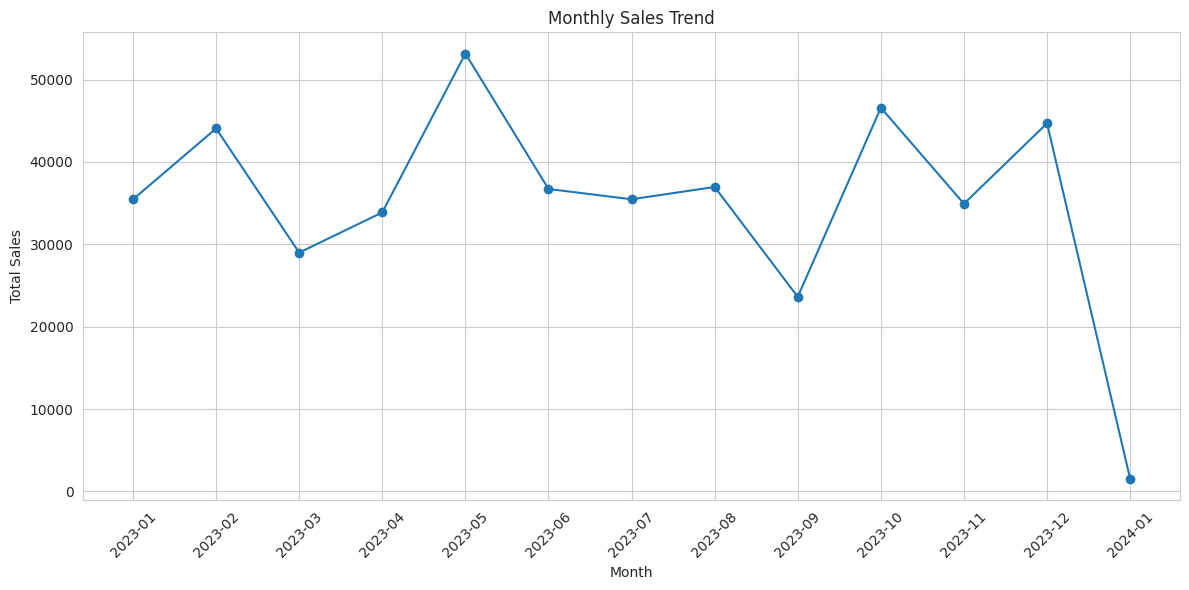

In [16]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [17]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales

,Total Amount
Date,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


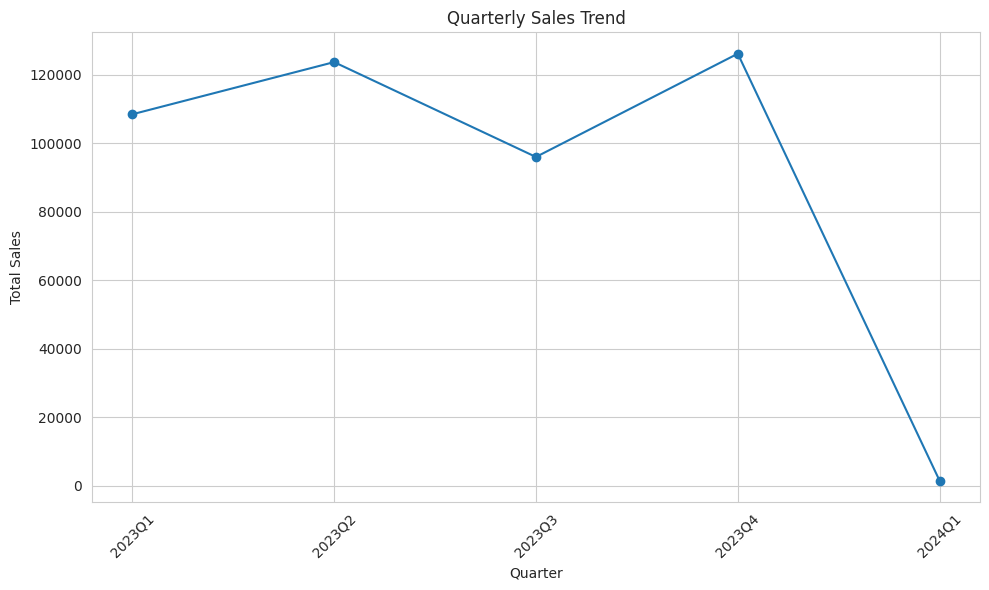

In [18]:
quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [19]:
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['Below 20', '20-29', '30-39', '40-49', '50-59', '60+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False
)

age_group_counts = df['Age Group'].value_counts().sort_index()

age_group_counts

,count
Age Group,
Below 20,42
20-29,209
30-39,191
40-49,222
50-59,221
60+,115


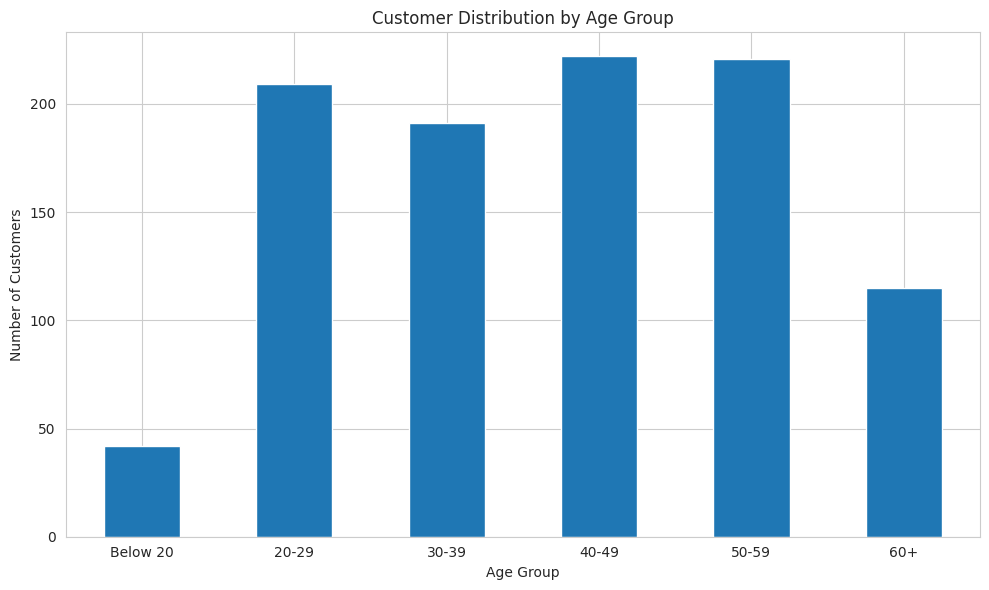

In [20]:
plt.figure(figsize=(10, 6))

age_group_counts.plot(
    kind='bar'
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
gender_counts = df['Gender'].value_counts()

gender_counts

,count
Gender,
Female,510
Male,490


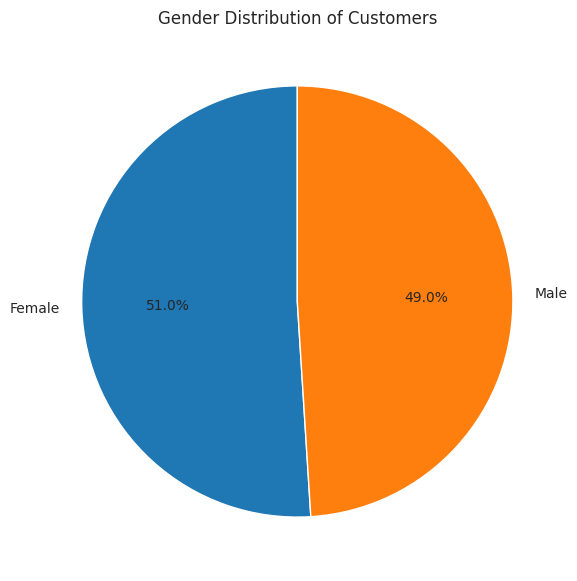

In [22]:
plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution of Customers')

plt.show()

In [23]:
category_analysis = df.groupby('Product Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Total Amount', 'sum'),
    Average_Transaction=('Total Amount', 'mean'),
    Number_of_Transactions=('Transaction ID', 'count')
)

category_analysis

,Total_Quantity,Total_Revenue,Average_Transaction,Number_of_Transactions
Product Category,,,,
Beauty,771,143515,467.475570,307
Clothing,894,155580,443.247863,351
Electronics,849,156905,458.786550,342


In [24]:
category_counts = df['Product Category'].value_counts()

category_counts

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


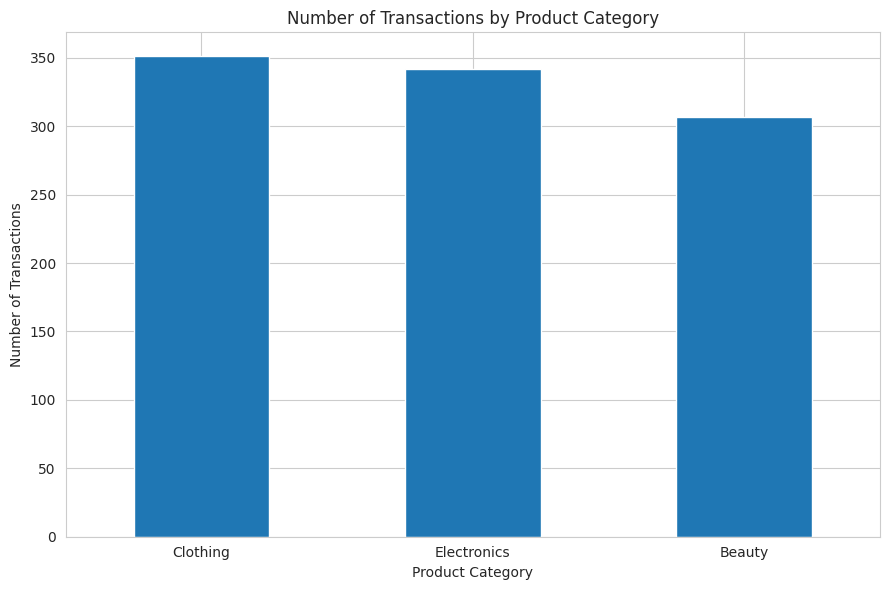

In [25]:
plt.figure(figsize=(9, 6))

category_counts.plot(kind='bar')

plt.title('Number of Transactions by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

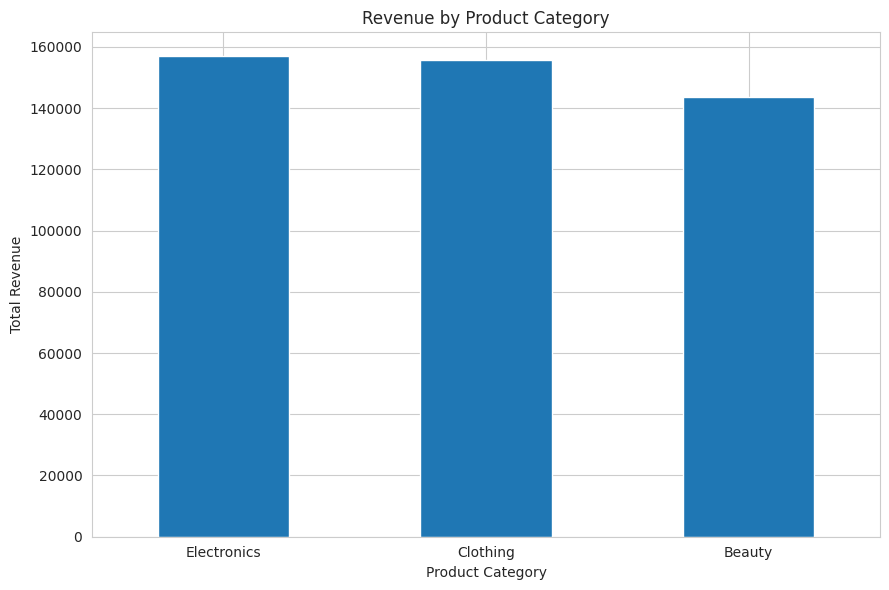

In [26]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(9, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

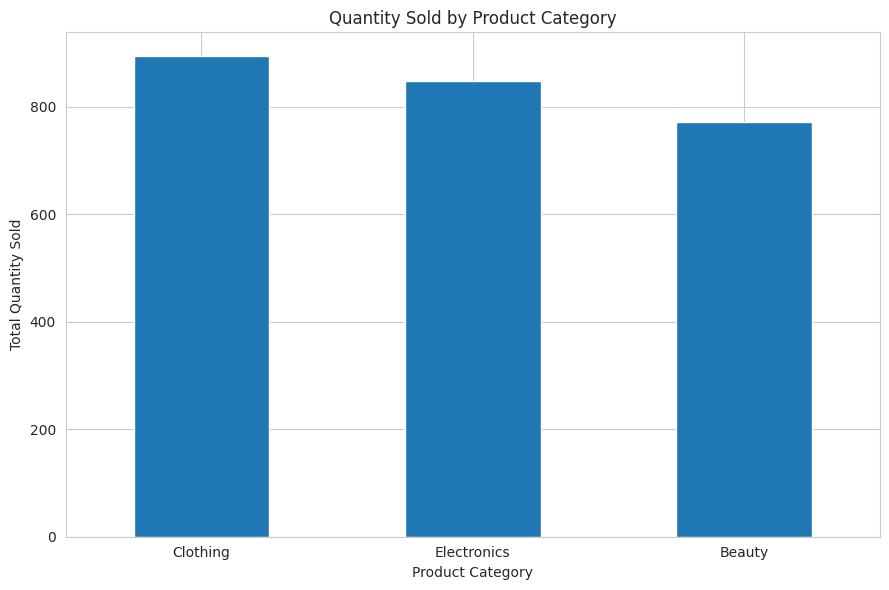

In [27]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(9, 6))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

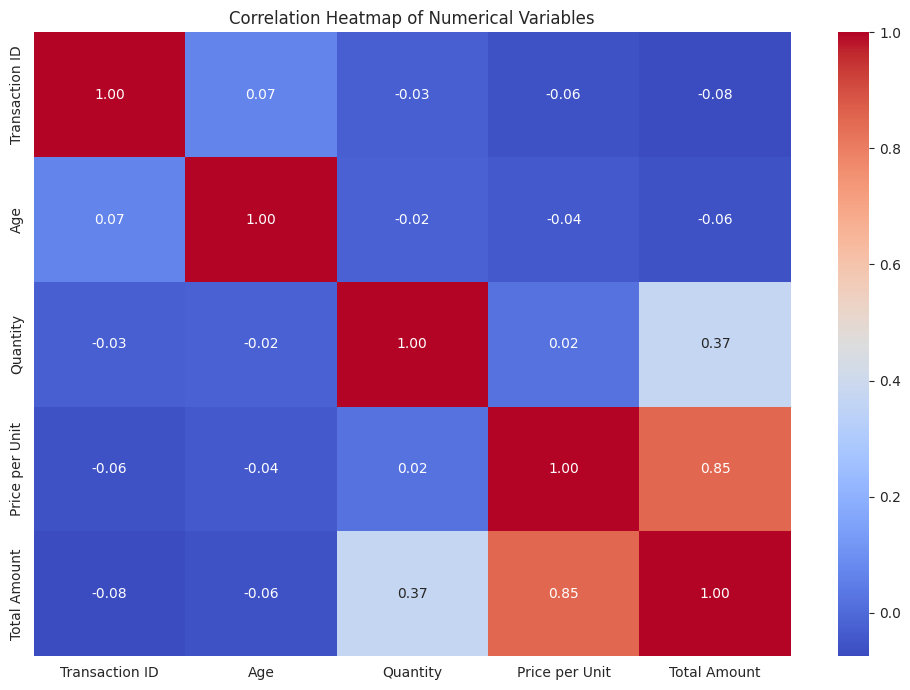

In [28]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [29]:
age_group_spending = df.groupby('Age Group', observed=True)['Total Amount'].mean()

age_group_spending

,Total Amount
Age Group,
Below 20,621.071429
20-29,464.449761
30-39,504.319372
40-49,420.563063
50-59,444.977376
60+,389.695652


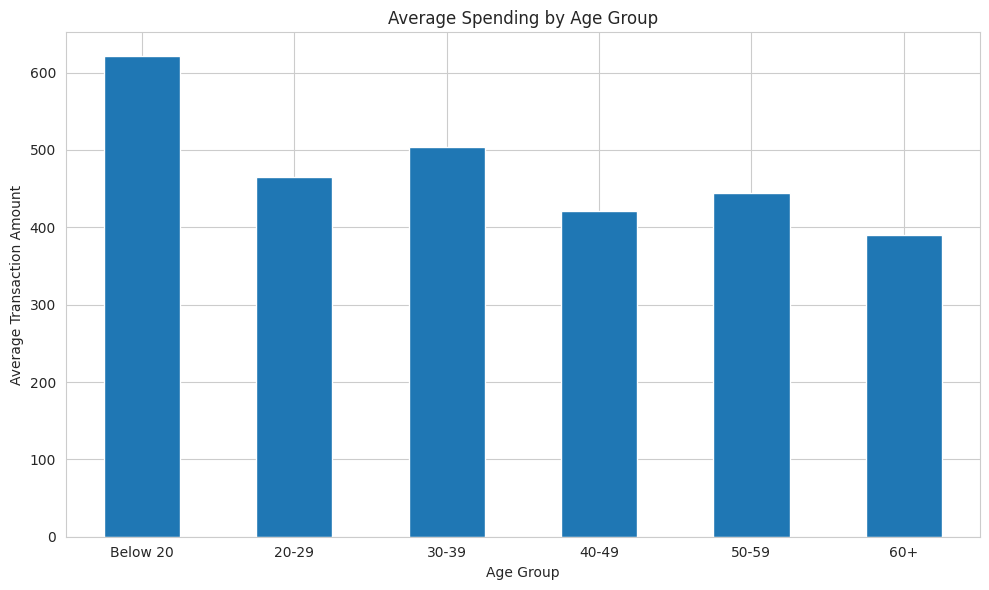

In [30]:
plt.figure(figsize=(10, 6))

age_group_spending.plot(kind='bar')

plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()